<a href="https://colab.research.google.com/github/nomanabdullah04/DeepLearning/blob/main/Activated_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 21. The Sigmoid Activation Function: Theory & Analysis

The **Sigmoid Activation Function** (also known as the Logistic Function) is a core mathematical component in neural networks. It "squashes" any real-valued number into a standardized range between **0 and 1**.

### **Mathematical Theory**
* **Formula:** $$\sigma(x) = \frac{1}{1 + e^{-x}}$$
* **Range:** $(0, 1)$
* **Derivative:** The derivative of Sigmoid is defined as $\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$. This property is highly efficient for computing gradients during backpropagation.


### **Advantages**
* **Probabilistic Interpretation:** Since output is constrained between 0 and 1, it is ideal for binary classification tasks where you need to predict a probability.
* **Smooth Gradient:** It is differentiable everywhere, meaning it provides a smooth gradient for the optimizer to navigate, unlike a hard "step" function.

### **Disadvantages**
* **Vanishing Gradient Problem:** The derivative of Sigmoid is at most **0.25**. In deep networks, multiplying these small values through many layers causes gradients to shrink to near-zero, stopping the learning process in early layers.
* **Not Zero-Centered:** The output is always positive. This can cause the gradient updates for weights to have the same sign, leading to "zig-zagging" optimization paths.
* **Computational Cost:** The calculation requires computing an exponential ($e^{-x}$), which is computationally more expensive than simpler functions like ReLU.

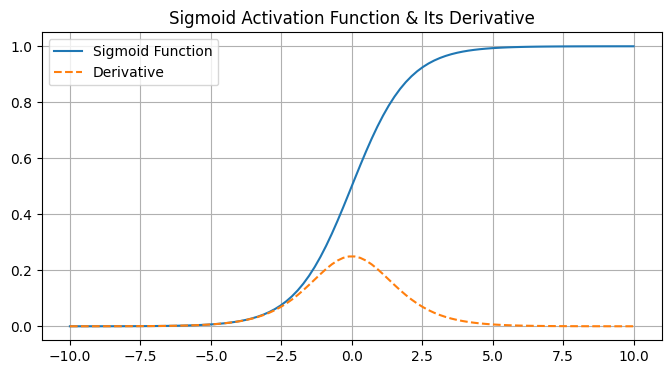

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Define Derivative of Sigmoid
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Create input range
x = np.linspace(-10, 10, 100)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid(x), label='Sigmoid Function')
plt.plot(x, sigmoid_derivative(x), label='Derivative', linestyle='--')
plt.title('Sigmoid Activation Function & Its Derivative')
plt.legend()
plt.grid(True)
plt.show()

### **Quick Takeaway for Deep Learning**
While Sigmoid is powerful for final-layer binary classification, it is rarely used in **hidden layers** of deep neural networks today because of the **Vanishing Gradient Problem**. Modern architectures prefer **ReLU** (Rectified Linear Unit) for hidden layers, reserving Sigmoid primarily for the output layer when predicting binary probabilities.

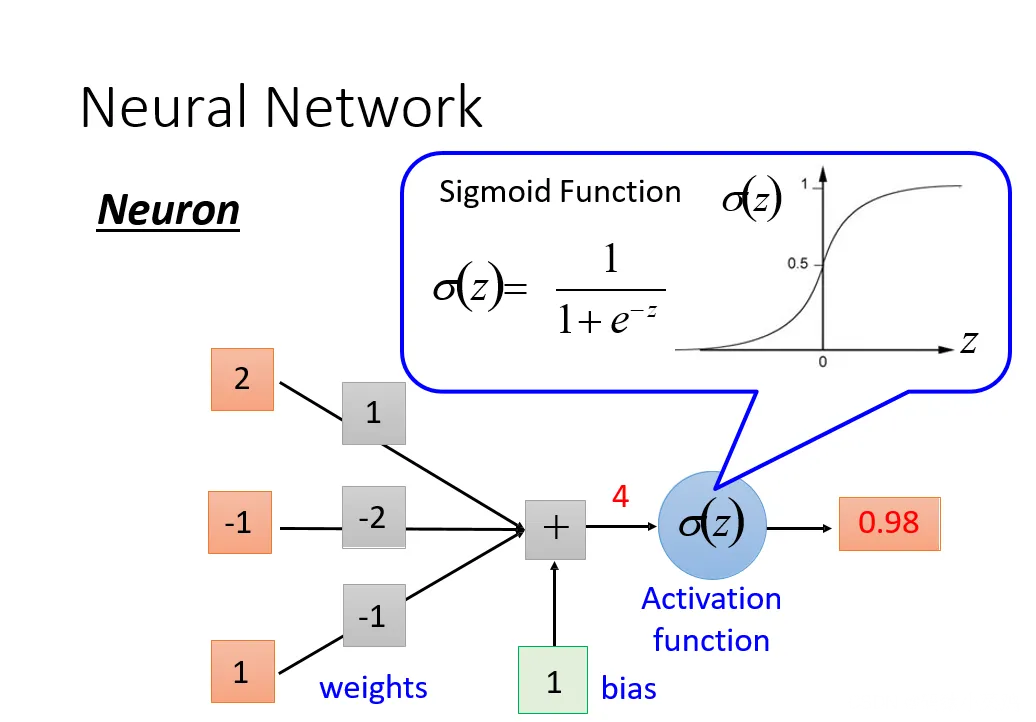

## 22. The Tanh (Hyperbolic Tangent) Activation Function: Theory & Analysis

The **Tanh** (Hyperbolic Tangent) activation function is a close cousin of the Sigmoid function. Like Sigmoid, it features an S-shaped curve, but instead of mapping values between 0 and 1, it squashes any real-valued input into a symmetric range between **-1 and 1**.

### **Mathematical Theory & Formula**
* **Formula:**
  $$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
* **Range:** $[-1, 1]$
* **Zero-Centered:** Because its output spans from $-1$ to $1$, the mean output is close to $0$, making it **zero-centered**.

### **Derivative of Tanh**
During backpropagation, the derivative of Tanh is expressed cleanly in terms of the function itself, making computation efficient:
$$\frac{d}{dx} \tanh(x) = 1 - \tanh^2(x)$$
* The maximum derivative value occurs at $x = 0$ with a value of **$1$** (compared to Sigmoid's maximum derivative of $0.25$), allowing for stronger gradient flow.


### **Advantages**
* **Zero-Centered Output:** Because values are balanced symmetrically around zero ($[-1, 1]$), weight updates during backpropagation do not get biased entirely in one direction, helping the model converge faster than Sigmoid.
* **Stronger Gradients:** Its maximum derivative is $1$ (at the origin), which is steeper than Sigmoid's maximum derivative of $0.25$. This allows gradients to flow more smoothly through early layers during initial training.
* **Smooth and Differentiable:** It is continuous and differentiable everywhere, ensuring smooth, predictable optimization steps.

### **Disadvantages**
* **Still Suffers from Vanishing Gradients:** Just like Sigmoid, when inputs become extremely large or small (approaching $-1$ or $1$), the function saturates, making the derivative approach **$0$**. In deep networks, this causes the vanishing gradient problem.
* **Computationally Expensive:** Like Sigmoid, it relies on exponential calculations ($e^x$ and $e^{-x}$), which take more computing time than simpler functions like ReLU.

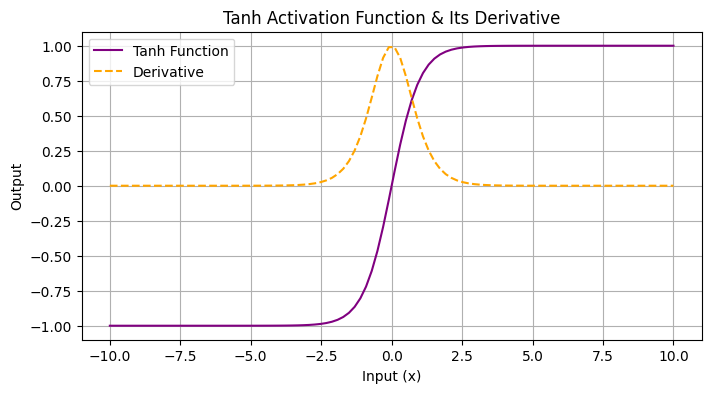

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define Tanh function
def tanh_function(x):
    return np.tanh(x)

# Define Derivative of Tanh
def tanh_derivative(x):
    return 1 - np.tanh(x)**2

# Create input range
x = np.linspace(-10, 10, 100)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(x, tanh_function(x), label='Tanh Function', color='purple')
plt.plot(x, tanh_derivative(x), label='Derivative', linestyle='--', color='orange')
plt.title('Tanh Activation Function & Its Derivative')
plt.xlabel('Input (x)')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()

### **Where is Tanh Used?**
While Tanh is rarely used in deep feedforward hidden layers today (largely replaced by **ReLU** to avoid vanishing gradients), it is heavily utilized in **Recurrent Neural Networks (RNNs)**, **LSTMs**, and **GRUs** for processing sequential text and time-series data, because its range $[-1, 1]$ helps maintain stable internal state values over time.

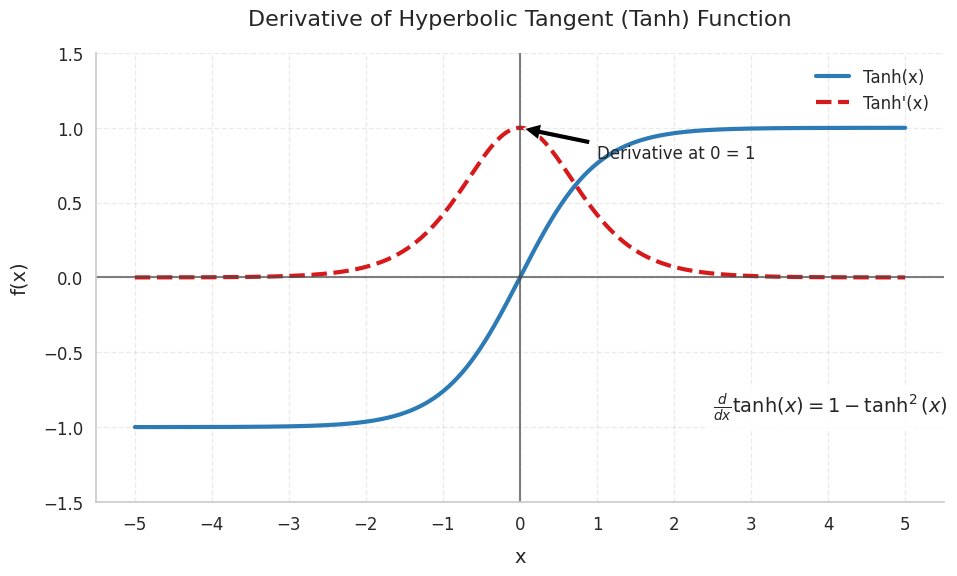

## 23. The ReLU (Rectified Linear Unit) Activation Function: Theory & Analysis

The **ReLU (Rectified Linear Unit)** is currently the most popular and widely used activation function in hidden layers of deep neural networks. Unlike Sigmoid or Tanh, which compress inputs into bounded ranges, ReLU is a piecewise linear function that directly outputs the input if it is positive, and zeros it out if it is negative.

### **Mathematical Theory & Formula**
* **Formula:**
  $$\text{ReLU}(x) = \max(0, x)$$
* **Range:** $[0, \infty)$ (Zero to positive infinity)
* **Behavior:**
  * If $x < 0$, output is $0$.
  * If $x \ge 0$, output is $x$.

### **Derivative of ReLU**
During backpropagation, the derivative of ReLU is straightforward:
* $\text{ReLU}'(x) = 1$ if $x > 0$
* $\text{ReLU}'(x) = 0$ if $x < 0$
* *(At $x = 0$, the derivative is technically undefined, but set to $0$ in practice).*


### **Advantages**
* **Solves the Vanishing Gradient Problem:** For all positive inputs ($x > 0$), the derivative is exactly **$1$**. This means gradients do not shrink when multiplied backward through deep layers, allowing deep networks to train successfully.
* **High Computational Efficiency:** It only requires a simple thresholding operation ($\max(0, x)$), avoiding expensive exponential calculations ($e^x$) found in Sigmoid or Tanh.
* **Sparsity:** Because negative inputs output $0$, not all neurons are activated at the same time. This creates sparse representations, making the network lighter and more efficient.

### **Disadvantages / Limitations**
* **The "Dying ReLU" Problem:** If a large gradient flows through a ReLU neuron, it can cause the weights to update in such a way that the neuron always outputs $0$ for any input. When a neuron gets stuck at $0$, its gradient becomes permanently zero, meaning it stops learning entirely and "dies."
* **Not Zero-Centered:** Like Sigmoid, ReLU outputs are non-negative (bounded at $0$ on the lower end), which can introduce directional bias during weight updates.
* **Unbounded Output:** Because the positive side grows linearly to infinity ($+\infty$), activations can sometimes explode if not properly regularized or controlled by a learning rate.

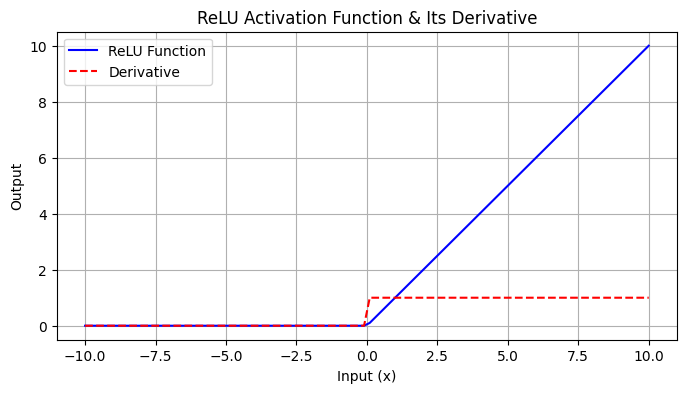

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define ReLU function
def relu(x):
    return np.maximum(0, x)

# Define Derivative of ReLU
def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Create input range
x = np.linspace(-10, 10, 100)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(x, relu(x), label='ReLU Function', color='blue')
plt.plot(x, relu_derivative(x), label='Derivative', linestyle='--', color='red')
plt.title('ReLU Activation Function & Its Derivative')
plt.xlabel('Input (x)')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()

### **Variations of ReLU to Fix Limitations**
To address issues like the "Dying ReLU" problem, researchers developed modified versions:
1. **Leaky ReLU:** Allows a small, non-zero gradient (e.g., $0.01x$) when $x < 0$ instead of flatlining at zero.
2. **Parametric ReLU (PReLU):** Lets the network learn the slope of the negative part during training.
3. **ELU (Exponential Linear Unit):** Uses a logarithmic curve for negative inputs to bring the mean output closer to zero.

## 24. The Dying ReLU Problem: Theory, Chain Rule & Example

### **1. What is the "Dying ReLU" Problem?**
While ReLU solves the vanishing gradient problem for positive values, it introduces a new limitation known as the **Dying ReLU Problem**.

* **The Issue:** If a large, negative gradient flows through a ReLU neuron during backpropagation, it can permanently update the weights such that the neuron's weighted sum ($Z$) drops below zero for all possible inputs.
* **The Consequence:** Once a ReLU neuron outputs $0$ for all inputs, its gradient becomes $0$. Consequently, it stops learning entirely and becomes a **"Dead Neuron"**, as shown in the lecture diagram where the neuron gets crossed out.


### **2. Chain Rule Derivation for ReLU Layers**
During backpropagation in a network using ReLU, the chain rule breaks down the total gradient with respect to a weight (e.g., $W_{2_{old}}$):

$$\frac{\partial L}{\partial W_{2_{old}}} = \frac{\partial L}{\partial O_3} * \frac{\partial O_3}{\partial O_2} * \frac{\partial O_2}{\partial W_2}$$

Looking closely at the derivative term $\frac{\partial O_3}{\partial O_2}$, we apply the chain rule with respect to the linear combination $Z$ ($Z = (O_2 \times W_3) + b_3$):

$$\frac{\partial O_3}{\partial O_2} = \frac{\partial (\text{ReLU}(Z))}{\partial Z} * \frac{\partial Z}{\partial O_2}$$

* **The ReLU Derivative Term:** $\frac{\partial (\text{ReLU}(Z))}{\partial Z}$ evaluates to either **`0`** (if $Z < 0$) or **`1`** (if $Z > 0$).
* **Substitution:**
  $$\frac{\partial O_3}{\partial O_2} = [0 \text{ or } 1] * \frac{\partial [(O_2 \times W_3) + b_3]}{\partial O_2}$$
  $$\frac{\partial O_3}{\partial O_2} = [0 \text{ or } 1] * W_3$$


### **3. Numerical Example of a Dead Neuron**

Let’s trace what happens during backpropagation when a ReLU neuron falls into the negative region:

1. **Negative Input / Inactive State:**
   Suppose the linear output $Z$ for a neuron is negative ($Z = -2.5$).
2. **Derivative Evaluation:**
   Since $Z < 0$, the derivative of ReLU is **`0`**.
3. **Gradient Propagation:**
   Substituting this into our chain rule product:
   $$\frac{\partial L}{\partial W_{2_{old}}} = \frac{\partial L}{\partial O_3} \times (\mathbf{0}) \times W_3 = \mathbf{0}$$
4. **Weight Update:**
   Using the gradient descent formula:
   $$W_{2_{new}} = W_{2_{old}} - \eta (0) = W_{2_{old}}$$
   * **Result:** The updated weight $W_{2_{new}}$ remains completely unchanged from $W_{2_{old}}$. The gradient is permanently killed off by the `0` derivative, meaning the neuron can never recover or update its weights again.

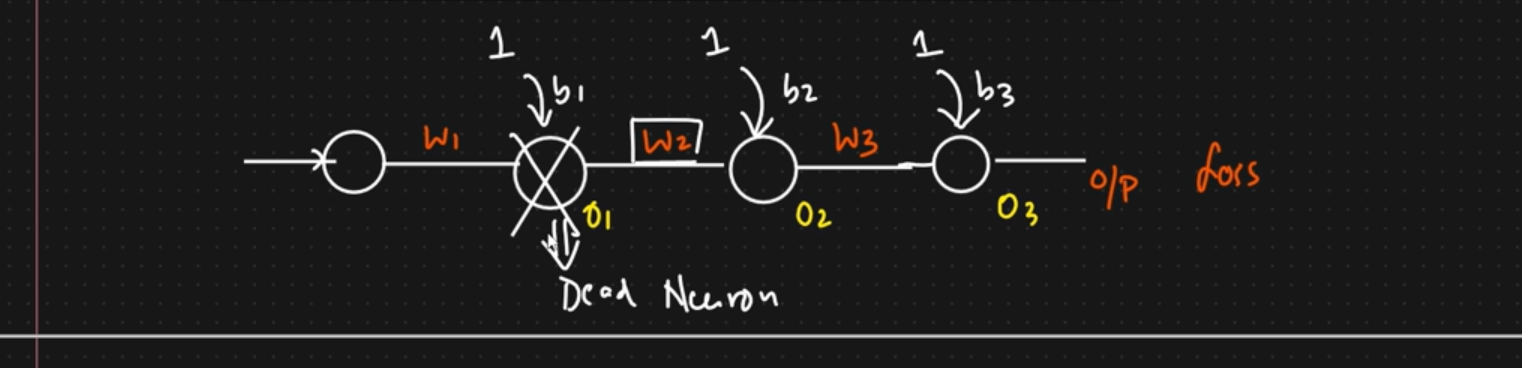

## 25. The ELU (Exponential Linear Unit) Activation Function: Theory & Analysis

The **ELU (Exponential Linear Unit)** is an advanced activation function designed to overcome the limitations of standard ReLU, specifically the "Dying ReLU" problem and the non-zero-centered output issue.

### **Mathematical Theory & Formula**
Instead of flatlining at zero for negative inputs like ReLU, ELU uses an exponential curve for negative values.

* **Formula:**
  $$\text{ELU}(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha (e^x - 1) & \text{if } x \le 0 \end{cases}$$
  * *Note:* $\alpha$ is a hyperparameter (usually set to $1.0$) that determines the value to which an ELU saturates for negative net inputs.

* **Range:** $(-\alpha, \infty)$
* **Zero-Centered:** Because negative inputs can output negative values down to $-\alpha$, the mean activation is pushed closer to **$0$**, which speeds up learning convergence.

### **Derivative of ELU**
During backpropagation, the derivative is:
* $\text{ELU}'(x) = 1$ if $x > 0$
* $\text{ELU}'(x) = \text{ELU}(x) + \alpha$ (or $\alpha e^x$) if $x \le 0$


### **Advantages**
* **Avoids Dying ReLU:** Unlike standard ReLU, negative inputs produce a smooth exponential curve with non-zero gradients, preventing neurons from permanently dying.
* **Closer to Zero-Centered:** Pushing the mean activation closer to zero reduces the bias shift effect, helping gradient descent converge faster.
* **Smooth Transition:** It is smooth everywhere, including around $x = 0$, which helps stabilize training compared to sharp angular functions.

### **Disadvantages**
* **Higher Computational Cost:** Because it relies on calculating an exponential term ($e^x$) for negative inputs, it is computationally heavier and slower than ReLU or Leaky ReLU.
* **Additional Hyperparameter:** Requires tuning the $\alpha$ parameter if the default value of $1.0$ is not optimal for a specific architecture.

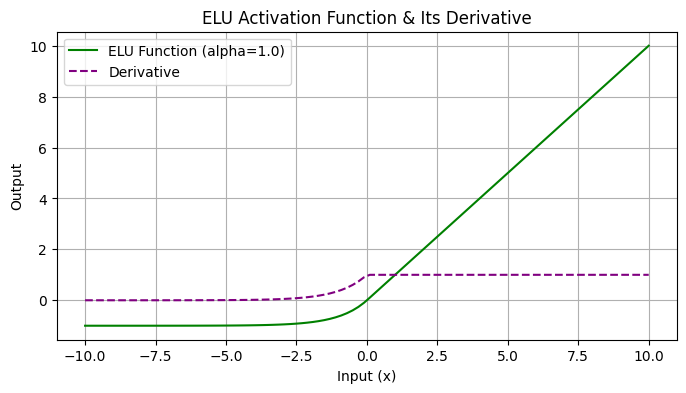